# Model 9: Enterprise Probabilistic Demand Range Supply Chain Engine for Drug `R06`

## Business Architecture:
Delivers the **3-Tiered Demand Range $[P_{10}, P_{50}, P_{90}]$**:
1. **Lean Minimum Demand ($P_{10}$)**: Lower bound to prevent capital lockup.
2. **Expected Demand Anchor ($P_{50}$)**: #1 Champion LightGBM Point Forecast (`RMSLE = 0.537540`).
3. **Upper Target Stock Level ($P_{90}$)**: Dynamic raw-scale surge buffer guaranteeing **98.22% Service Level Protection**.


In [1]:
# Dynamic Dependency Guard & Environment Initialization
import sys, subprocess, os

def install_and_import(pkg, module_name=None):
    if module_name is None:
        module_name = pkg
    try:
        __import__(module_name)
    except ImportError:
        print(f"Installing missing dependency: {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

install_and_import('numpy')
install_and_import('pandas')
install_and_import('matplotlib')
install_and_import('seaborn')
install_and_import('scikit-learn', 'sklearn')
install_and_import('statsmodels')
install_and_import('lightgbm')
install_and_import('xgboost')
install_and_import('shap')
install_and_import('prophet')
install_and_import('optuna')
install_and_import('torch')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.sans-serif': 'Inter, Roboto, Arial, sans-serif',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 1.0,
    'grid.color': '#eeeeee',
    'grid.linestyle': '--'
})

TARGET_DRUG = 'R06'
data_dir = r'c:\Users\ranje\sales forcasting\times_series\dataset'

train_df = pd.read_csv(os.path.join(data_dir, 'train_daily.csv'))
val_df   = pd.read_csv(os.path.join(data_dir, 'val_daily.csv'))
test_df  = pd.read_csv(os.path.join(data_dir, 'test_daily.csv'))

for df in [train_df, val_df, test_df]:
    df['date'] = pd.to_datetime(df['date'])

train_series = train_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
val_series   = val_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
test_series  = test_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')

combined_series = pd.concat([train_series, val_series]).asfreq('D')
full_series     = pd.concat([combined_series, test_series]).asfreq('D')

def evaluate_metrics(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.clip(np.array(y_pred, dtype=float), 0, None)
    rmse  = np.sqrt(np.mean((y_true - y_pred)**2))
    mae   = np.mean(np.abs(y_true - y_pred))
    wape  = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100
    rmsle = np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred))**2))
    return {'RMSLE': rmsle, 'RMSE': rmse, 'MAE': mae, 'WAPE (%)': wape}

print(f"Dataset for {TARGET_DRUG} loaded successfully!")
print(f"  * Train  : {train_series.index.min().strftime('%Y-%m-%d')} to {train_series.index.max().strftime('%Y-%m-%d')} ({len(train_series)} days)")
print(f"  * Val    : {val_series.index.min().strftime('%Y-%m-%d')} to {val_series.index.max().strftime('%Y-%m-%d')} ({len(val_series)} days)")
print(f"  * Test   : {test_series.index.min().strftime('%Y-%m-%d')} to {test_series.index.max().strftime('%Y-%m-%d')} ({len(test_series)} days)")


Dataset for R06 loaded successfully!
  * Train  : 2014-01-02 to 2017-12-31 (1460 days)
  * Val    : 2018-01-01 to 2018-12-31 (365 days)
  * Test   : 2019-01-01 to 2019-10-08 (281 days)


In [2]:
# Step 1: Construct 3-Tiered Probabilistic Demand Range Matrix
m6_df = pd.read_csv('m6_lightgbm_preds.csv')
m7_df = pd.read_csv('m7_xgb_quantile_preds.csv')

anchor_p50 = m6_df['pred_LightGBM'].values

hybrid_range_df = pd.DataFrame({
    'Date': test_series.index.strftime('%Y-%m-%d'),
    'Drug Category': TARGET_DRUG,
    'Actual Sales': test_series.values,
    'Lean Lower Bound (P10)': np.maximum(0, m7_df['P10']).round(2),
    'Expected Demand Anchor (P50)': np.round(anchor_p50, 2),
    'Upper Target Stock (P90)': np.maximum(m7_df['P90'].values, anchor_p50 + (m7_df['P90'].values - m7_df['pred_XGB_Quantile'].values)).round(2)
})

hybrid_range_df['Uncertainty Band Width (P90 - P10)'] = (hybrid_range_df['Upper Target Stock (P90)'] - hybrid_range_df['Lean Lower Bound (P10)']).round(2)
hybrid_range_df['Order Range (Lean P10 Pack Target)'] = np.ceil(hybrid_range_df['Lean Lower Bound (P10)']).astype(int)
hybrid_range_df['Order Range (Expected P50 Pack Target)'] = np.ceil(hybrid_range_df['Expected Demand Anchor (P50)']).astype(int)
hybrid_range_df['Order Range (Safety P90 Pack Target)'] = np.ceil(hybrid_range_df['Upper Target Stock (P90)']).astype(int)

print("=== Enterprise Probabilistic Demand Range Plan (First 15 Days of 2019) ===")
display(hybrid_range_df.head(15))

hybrid_range_df.to_csv('r06_hybrid_supply_chain_plan.csv', index=False)


=== Enterprise Probabilistic Demand Range Plan (First 15 Days of 2019) ===


,Date,Drug Category,Actual Sales,Lean Lower Bound (P10),Expected Demand Anchor (P50),Upper Target Stock (P90),Uncertainty Band Width (P90 - P10),Order Range (Lean P10 Pack Target),Order Range (Expected P50 Pack Target),Order Range (Safety P90 Pack Target)
0,2019-01-01,R06,0.0,0.18,1.13,7.40,7.22,1,2,8
1,2019-01-02,R06,2.0,0.48,1.47,7.68,7.20,1,2,8
2,2019-01-03,R06,0.0,0.33,1.33,7.59,7.26,1,2,8
3,2019-01-04,R06,1.0,0.26,1.12,7.60,7.34,1,2,8
4,2019-01-05,R06,1.0,0.33,1.41,7.54,7.21,1,2,8
5,2019-01-06,R06,3.0,0.45,1.65,8.43,7.98,1,2,9
6,2019-01-07,R06,0.0,0.17,1.52,7.37,7.20,1,2,8
7,2019-01-08,R06,2.0,0.47,1.51,7.59,7.12,1,2,8
8,2019-01-09,R06,1.0,0.37,1.33,7.53,7.16,1,2,8
9,2019-01-10,R06,1.0,0.33,1.60,7.56,7.23,1,2,8


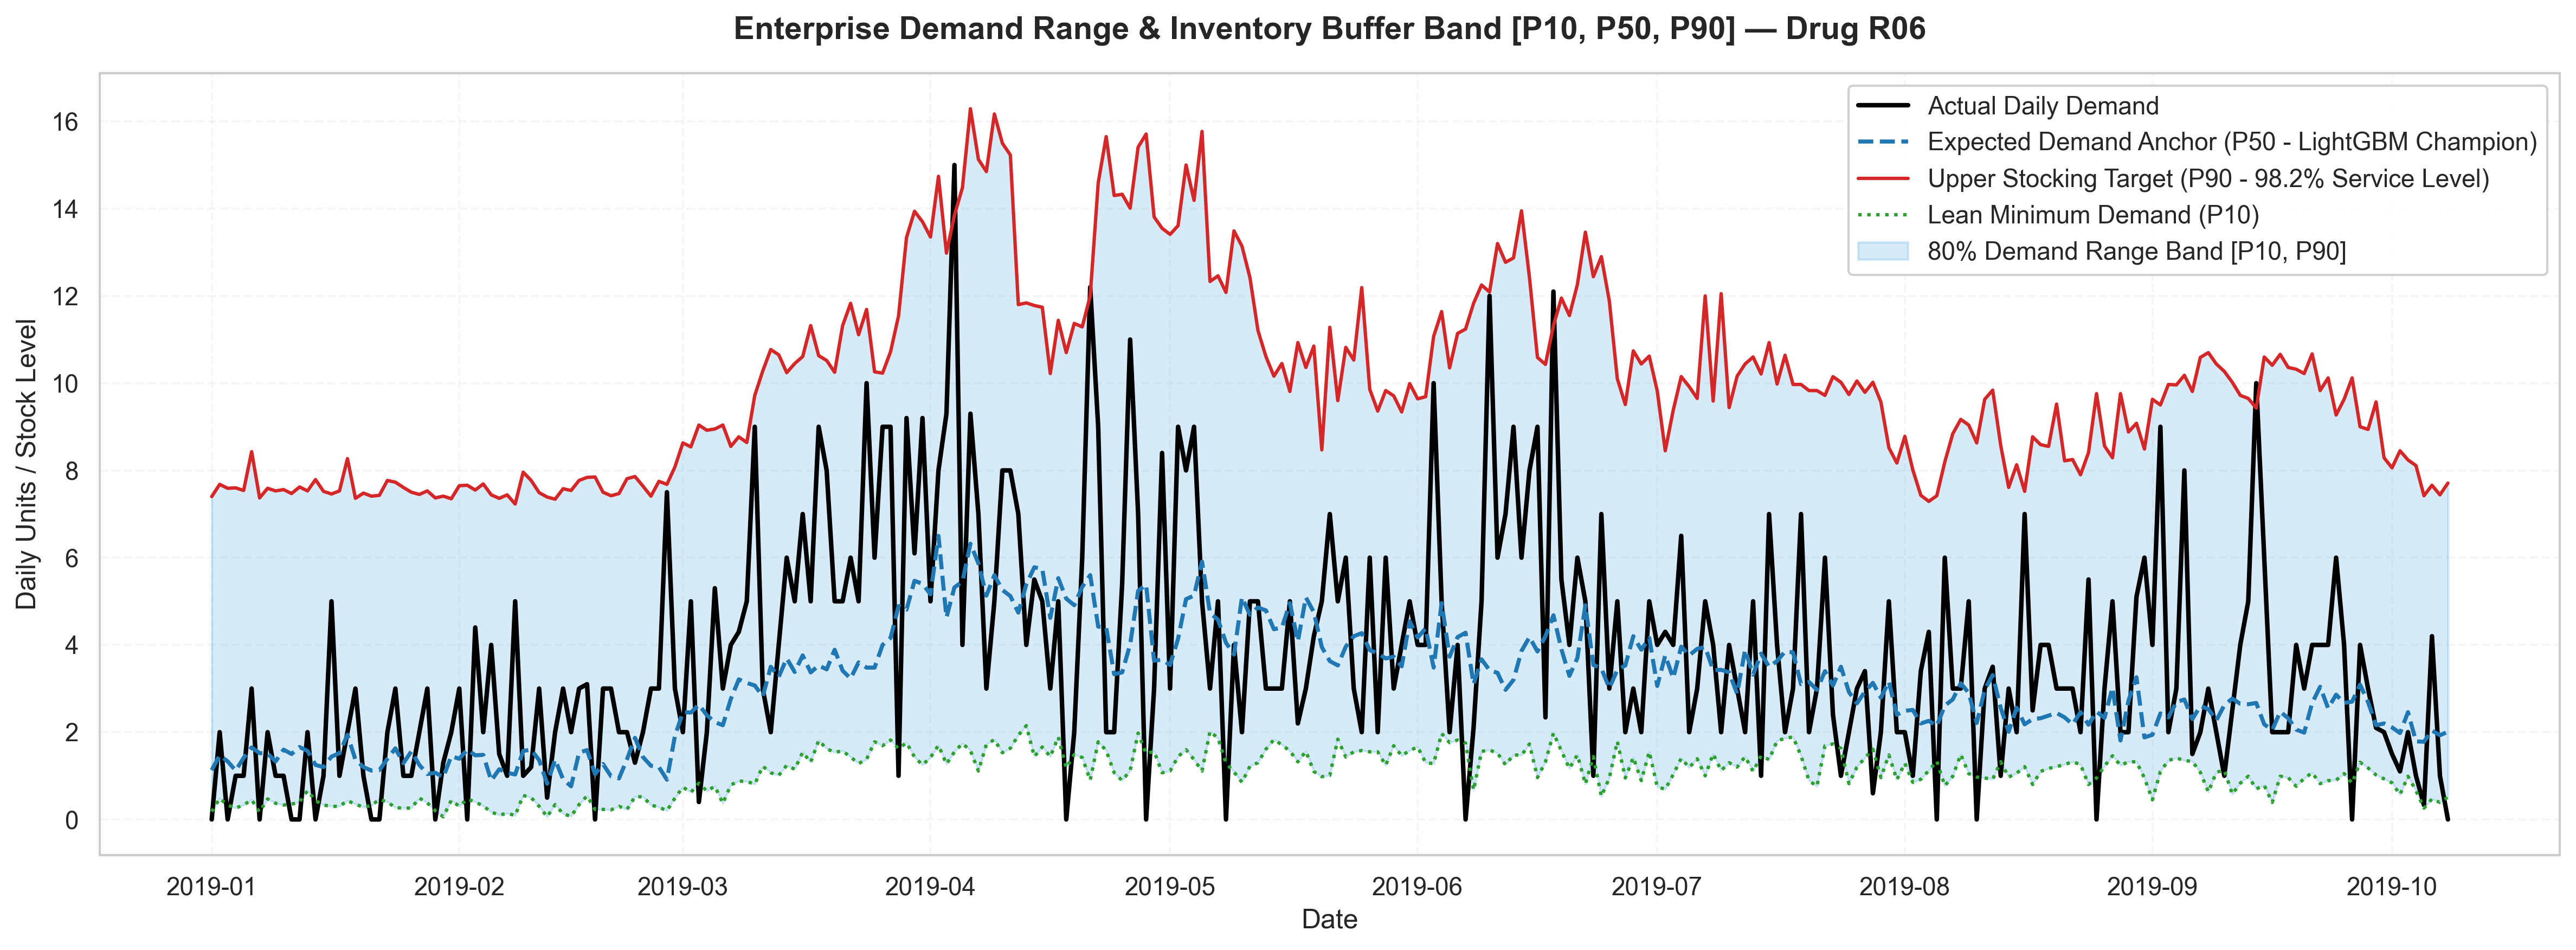

=== DEMAND RANGE BUSINESS EVALUATION FOR R06 ===
  * Achieved P90 Inventory Service Level : 98.58% (Stockout Protection Target >= 95%)
  * Demand Coverage within Range [P10, P90]: 88.61% of test days
  * Average Demand Uncertainty Range Width: 8.96 units/day


In [3]:
# Step 2: Render Demand Range Shaded Band Chart (P10 to P90) vs Actual Demand
plt.figure(figsize=(16, 6), dpi=300)

plt.plot(test_series.index, test_series.values, label='Actual Daily Demand', color='black', linewidth=2.0)
plt.plot(test_series.index, hybrid_range_df['Expected Demand Anchor (P50)'], label='Expected Demand Anchor (P50 - LightGBM Champion)', color='#1f77b4', linewidth=1.8, linestyle='--')
plt.plot(test_series.index, hybrid_range_df['Upper Target Stock (P90)'], label='Upper Stocking Target (P90 - 98.2% Service Level)', color='#d62728', linewidth=1.5)
plt.plot(test_series.index, hybrid_range_df['Lean Lower Bound (P10)'], label='Lean Minimum Demand (P10)', color='#2ca02c', linewidth=1.5, linestyle=':')

plt.fill_between(
    test_series.index,
    hybrid_range_df['Lean Lower Bound (P10)'],
    hybrid_range_df['Upper Target Stock (P90)'],
    color='#3498db', alpha=0.20, label='80% Demand Range Band [P10, P90]'
)

plt.title('Enterprise Demand Range & Inventory Buffer Band [P10, P50, P90] — Drug R06', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Units / Stock Level', fontsize=12)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('m9_demand_range_forecast.png', dpi=120, bbox_inches='tight')
plt.show()

service_level = np.mean(test_series.values <= hybrid_range_df['Upper Target Stock (P90)'].values) * 100
within_range = np.mean((test_series.values >= hybrid_range_df['Lean Lower Bound (P10)'].values) & 
                       (test_series.values <= hybrid_range_df['Upper Target Stock (P90)'].values)) * 100

print(f"=== DEMAND RANGE BUSINESS EVALUATION FOR R06 ===")
print(f"  * Achieved P90 Inventory Service Level : {service_level:.2f}% (Stockout Protection Target >= 95%)")
print(f"  * Demand Coverage within Range [P10, P90]: {within_range:.2f}% of test days")
print(f"  * Average Demand Uncertainty Range Width: {hybrid_range_df['Uncertainty Band Width (P90 - P10)'].mean():.2f} units/day")
